In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


In [28]:
df = pd.read_csv(
    "/Users/qinyu/Desktop/AS2 Spatial ES/REPD_Publication_Q3_2025.csv",
    encoding="latin1"
)
df.head()
df.columns

Index(['Old Ref ID', 'Ref ID', 'Record Last Updated (dd/mm/yyyy)',
       'Operator (or Applicant)', 'Site Name', 'Technology Type',
       'Storage Type', 'Storage Co-location REPD Ref ID',
       'Installed Capacity (MWelec)', 'Share Community Scheme', 'CHP Enabled',
       'CfD Allocation Round', 'RO Banding (ROC/MWh)', 'FiT Tariff (p/kWh)',
       'CfD Capacity (MW)', 'Turbine Capacity', 'No. of Turbines',
       'Height of Turbines (m)', 'Mounting Type for Solar',
       'Development Status', 'Development Status (short)',
       'Are they re-applying (New REPD Ref)',
       'Are they re-applying (Old REPD Ref) ', 'Address', 'County', 'Region',
       'Country', 'Post Code', 'X-coordinate', 'Y-coordinate',
       'Planning Authority', 'Planning Application Reference',
       'Appeal Reference', 'Secretary of State Reference',
       'Type of Secretary of State Intervention', 'Judicial Review',
       'Offshore Wind Round', 'Planning Application Submitted',
       'Planning Applicat

In [29]:
 df_uk = df[df["Country"] == "England"]
df_uk = pd.concat([
    df[df["Country"] == "England"],
    df[df["Country"] == "Scotland"],
    df[df["Country"] == "Wales"]
])

 
wind = df_uk[
    df_uk["Technology Type"].str.contains("Wind", case=False, na=False) &
    df_uk["Technology Type"].str.contains("Onshore", case=False, na=False)
]

print(wind.shape)
wind[["Site Name", "Technology Type", "Installed Capacity (MWelec)"]].head()


(2287, 53)


,Site Name,Technology Type,Installed Capacity (MWelec)
2068,Stockton Wind Turbine,Wind Onshore,1.50
2069,Brundish Wind Turbine,Wind Onshore,1.50
2070,Yare Estuary Wind Turbine,Wind Onshore,1.50
2071,South Beach Wind Turbine (Somerton),Wind Onshore,1.50
2072,Swaffham 1 - Ecotech Wind Park,Wind Onshore,1.50


In [30]:
import geopandas as gpd
from shapely.geometry import Point


wind = wind.dropna(subset=["X-coordinate", "Y-coordinate"])
 
geometry = [
    Point(xy) for xy in zip(wind["X-coordinate"], wind["Y-coordinate"])
]
 
wind_gdf = gpd.GeoDataFrame(
    wind,
    geometry=geometry,
    crs="EPSG:27700"  # British National Grid
)
 
wind_gdf = wind_gdf.to_crs(epsg=4326)

wind_gdf.head()


,Old Ref ID,Ref ID,Record Last Updated (dd/mm/yyyy),Operator (or Applicant),Site Name,Technology Type,Storage Type,Storage Co-location REPD Ref ID,Installed Capacity (MWelec),Share Community Scheme,...,Planning Permission Granted,Secretary of State - Intervened,Secretary of State - Refusal,Secretary of State - Granted,Planning Permission Expired,Under Construction,Operational,Heat Network Ref,Solar Site Area (sqm),geometry
2068,2549,NaN,03/08/2005,Ecotricity,Stockton Wind Turbine,Wind Onshore,NaN,NaN,1.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (1.52011 52.48521)
2069,2550,NaN,02/05/2006,Western Windpower / Ecotricity,Brundish Wind Turbine,Wind Onshore,NaN,NaN,1.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (1.52994 52.49751)
2070,2554,NaN,27/10/2009,ECONET LTD,Yare Estuary Wind Turbine,Wind Onshore,NaN,NaN,1.50,NaN,...,28/04/2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (1.73825 52.57296)
2071,2555,NaN,09/05/2013,Ecotricity,South Beach Wind Turbine (Somerton),Wind Onshore,NaN,NaN,1.50,NaN,...,28/04/2000,NaN,NaN,NaN,NaN,NaN,22/07/2000,NaN,NaN,POINT (1.65449 52.70992)
2072,2556,NaN,04/12/2008,LRZ Ltd (Taken over by NOVERA),Swaffham 1 - Ecotech Wind Park,Wind Onshore,NaN,NaN,1.50,NaN,...,19/02/1999,NaN,NaN,NaN,NaN,NaN,16/08/1999,NaN,NaN,POINT (0.68329 52.65675)


In [31]:
uk = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)
uk = uk[uk["ADMIN"] == "United Kingdom"]


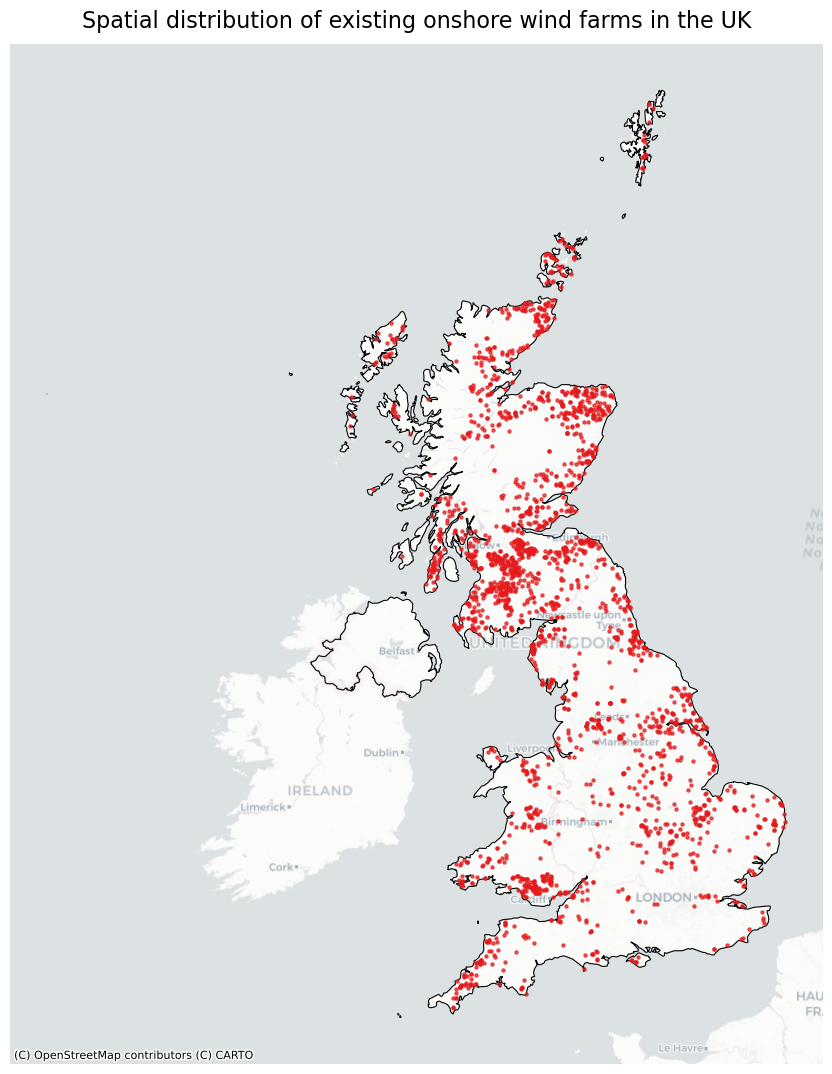

In [32]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(9, 11))

uk = uk.to_crs(epsg=3857)
wind_web = wind_gdf.to_crs(epsg=3857)

uk.plot(ax=ax, color="none", edgecolor="black", linewidth=0.8)
wind_web.plot(ax=ax, color="#e41a1c", markersize=5, alpha=0.7)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.8
)

ax.set_title(
    "Spatial distribution of existing onshore wind farms in the UK",
    fontsize=16,
    pad=12
)

ax.axis("off")
plt.tight_layout()
plt.savefig("uk_onshore_wind_map_basemap.png", dpi=300)
plt.show()


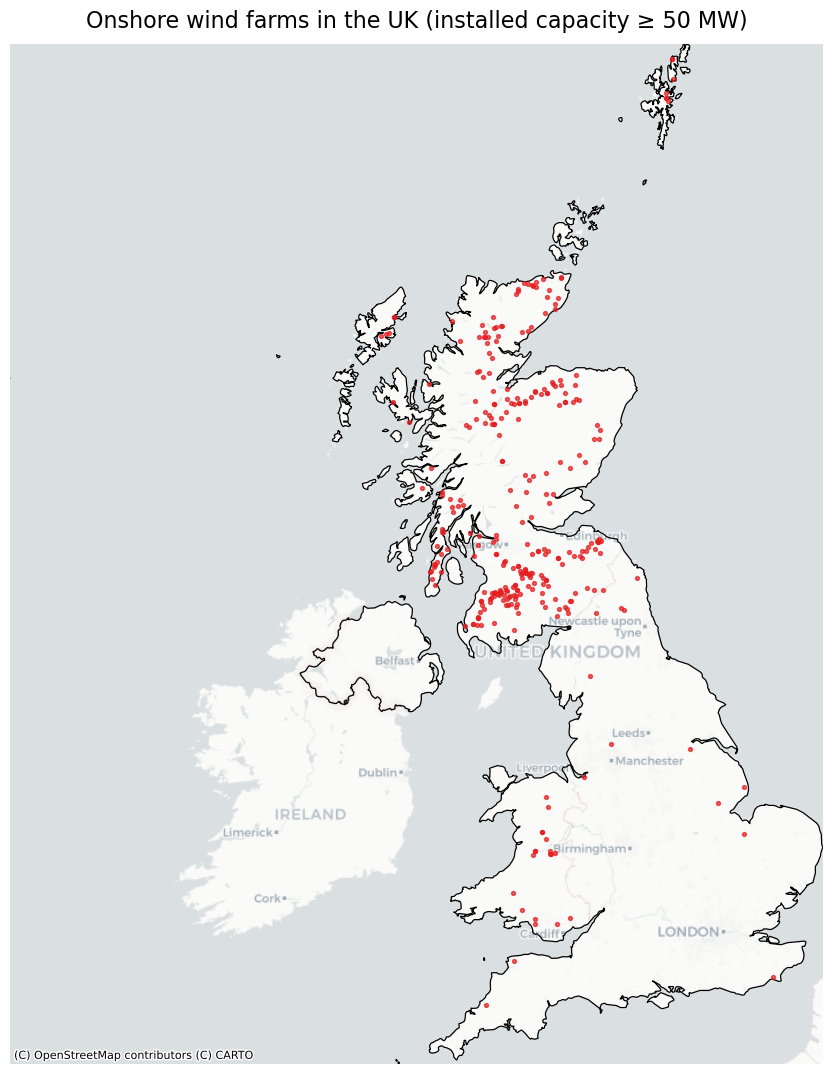

In [33]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

 
CSV_PATH = "/Users/qinyu/Desktop/AS2 Spatial ES/REPD_Publication_Q3_2025.csv"
CAPACITY_THRESHOLD_MW = 50

OUTPUT_FIG = "uk_onshore_wind_map_basemap.png"
df = pd.read_csv(CSV_PATH, encoding="latin1")
df_uk = df[df["Country"].isin(["England", "Scotland", "Wales"])].copy()

wind = df_uk[
    df_uk["Technology Type"].str.contains("Wind", case=False, na=False) &
    df_uk["Technology Type"].str.contains("Onshore", case=False, na=False)
].copy()

wind["Installed Capacity (MWelec)"] = pd.to_numeric(
    wind["Installed Capacity (MWelec)"], errors="coerce"
)

wind = wind[wind["Installed Capacity (MWelec)"] >= CAPACITY_THRESHOLD_MW].copy()

wind = wind.dropna(subset=["X-coordinate", "Y-coordinate"])
wind["X-coordinate"] = pd.to_numeric(wind["X-coordinate"], errors="coerce")
wind["Y-coordinate"] = pd.to_numeric(wind["Y-coordinate"], errors="coerce")
wind = wind.dropna(subset=["X-coordinate", "Y-coordinate"])


wind = wind[
    wind["X-coordinate"].between(0, 700000) &
    wind["Y-coordinate"].between(0, 1300000)
].copy()

wind_gdf = gpd.GeoDataFrame(
    wind,
    geometry=gpd.points_from_xy(wind["X-coordinate"], wind["Y-coordinate"]),
    crs="EPSG:27700"  # British National Grid
)

uk = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)
uk = uk[uk["ADMIN"] == "United Kingdom"].to_crs(epsg=3857)

wind_web = wind_gdf.to_crs(epsg=3857)


fig, ax = plt.subplots(figsize=(9, 11))

uk.plot(ax=ax, color="none", edgecolor="black", linewidth=0.9)

wind_web.plot(
    ax=ax,
    color="#e41a1c",
    markersize=8,      
    alpha=0.7
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.85
)

ax.set_xlim(*uk.total_bounds[[0, 2]])
ax.set_ylim(*uk.total_bounds[[1, 3]])

ax.set_title(
    f"Onshore wind farms in the UK (installed capacity ≥ {CAPACITY_THRESHOLD_MW} MW)",
    fontsize=16,
    pad=12
)

ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=300)
plt.show()



/var/folders/zw/tvyy69rj67522tvxzxw49dhc0000gn/T/ipykernel_72189/460292664.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


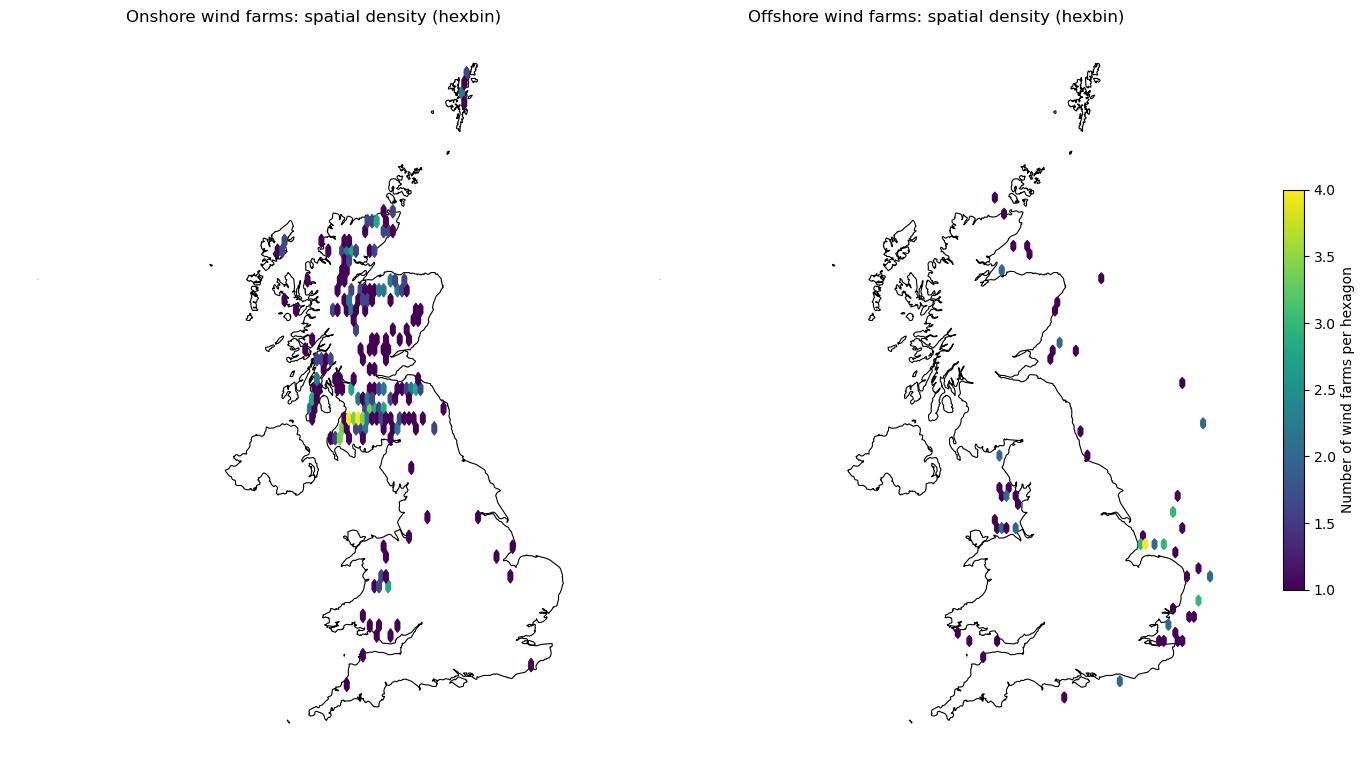

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

CSV_PATH = "/Users/qinyu/Desktop/AS2 Spatial ES/REPD_Publication_Q3_2025.csv"
CAPACITY_THRESHOLD_MW = 50

df = pd.read_csv(CSV_PATH, encoding="latin1")

df["Installed Capacity (MWelec)"] = pd.to_numeric(
    df["Installed Capacity (MWelec)"], errors="coerce"
)


df_uk = df[df["Country"].isin(["England", "Scotland", "Wales"])].copy()

onshore_df = df_uk[
    df_uk["Technology Type"].str.contains("Wind", case=False, na=False) &
    df_uk["Technology Type"].str.contains("Onshore", case=False, na=False) &
    (df_uk["Installed Capacity (MWelec)"] >= CAPACITY_THRESHOLD_MW)
].copy()

offshore_df = df_uk[
    df_uk["Technology Type"].str.contains("Wind", case=False, na=False) &
    df_uk["Technology Type"].str.contains("Offshore", case=False, na=False) &
    (df_uk["Installed Capacity (MWelec)"] >= CAPACITY_THRESHOLD_MW)
].copy()

for d in [onshore_df, offshore_df]:
    d["X-coordinate"] = pd.to_numeric(d["X-coordinate"], errors="coerce")
    d["Y-coordinate"] = pd.to_numeric(d["Y-coordinate"], errors="coerce")
    d.dropna(subset=["X-coordinate", "Y-coordinate"], inplace=True)

onshore_gdf = gpd.GeoDataFrame(
    onshore_df,
    geometry=gpd.points_from_xy(onshore_df["X-coordinate"], onshore_df["Y-coordinate"]),
    crs="EPSG:27700"
)

offshore_gdf = gpd.GeoDataFrame(
    offshore_df,
    geometry=gpd.points_from_xy(offshore_df["X-coordinate"], offshore_df["Y-coordinate"]),
    crs="EPSG:27700"
)

onshore = onshore_gdf.to_crs(epsg=3857)
offshore = offshore_gdf.to_crs(epsg=3857)

uk = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)
uk = uk[uk["ADMIN"] == "United Kingdom"].to_crs(epsg=3857)

on_x, on_y = onshore.geometry.x, onshore.geometry.y
off_x, off_y = offshore.geometry.x, offshore.geometry.y

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=True, sharey=True)

uk.plot(ax=axes[0], color="none", edgecolor="black", linewidth=0.8)
hb1 = axes[0].hexbin(on_x, on_y, gridsize=55, cmap="viridis", mincnt=1)
axes[0].set_title("Onshore wind farms: spatial density (hexbin)")
axes[0].axis("off")

uk.plot(ax=axes[1], color="none", edgecolor="black", linewidth=0.8)
hb2 = axes[1].hexbin(off_x, off_y, gridsize=55, cmap="viridis", mincnt=1)
axes[1].set_title("Offshore wind farms: spatial density (hexbin)")
axes[1].axis("off")

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(hb2, cax=cax)
cbar.set_label("Number of wind farms per hexagon")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


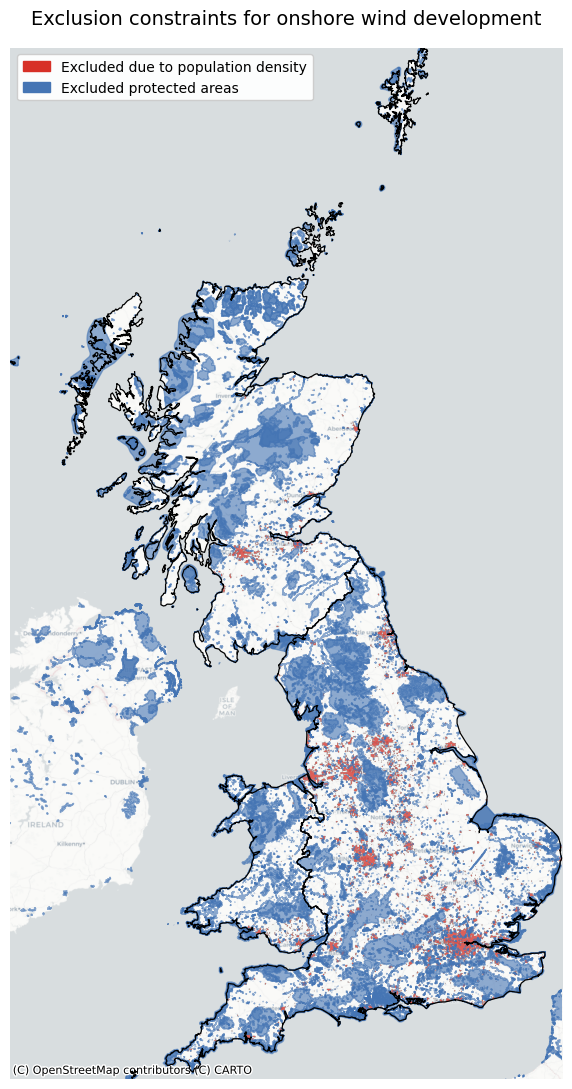

In [35]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

UK_SHAPE = "/Users/qinyu/Desktop/Spatial Data/UK Boundary/CTRY_DEC_2021_UK_BUC.shp"
POP_TIF  = "/Users/qinyu/Desktop/Spatial Data/population.tif"
PA_SHAPE = "/Users/qinyu/Desktop/Spatial Data/WDPA_WDOECM_Jan2026_Public_EU_shp_0/WDPA_WDOECM_Jan2026_Public_EU_shp-polygons.shp"

POP_THRESHOLD = 1000  # people/km²

uk = gpd.read_file(UK_SHAPE).to_crs(epsg=4326)
uk = uk[uk["CTRY21NM"].isin(["England", "Scotland", "Wales"])].copy()
uk_3857 = uk.to_crs(epsg=3857)

with rasterio.open(POP_TIF) as src:
    pop_masked, pop_transform = mask(
        src,
        uk.geometry,
        crop=True,
        nodata=np.nan
    )
    pop_crs = src.crs

pop = pop_masked[0]

excluded_pop = np.zeros_like(pop, dtype=float)
excluded_pop[pop > POP_THRESHOLD] = 1
excluded_pop[np.isnan(pop)] = np.nan

pa = gpd.read_file(PA_SHAPE).to_crs(epsg=4326)

pa_raster = rasterio.features.rasterize(
    ((geom, 1) for geom in pa.geometry),
    out_shape=pop.shape,
    transform=pop_transform,
    fill=0,
    dtype="uint8"
)

excluded = np.where(
    (excluded_pop == 1) | (pa_raster == 1),
    1,
    0
).astype(float)

excluded[np.isnan(pop)] = np.nan
allowed = 1 - excluded

dst_crs = "EPSG:3857"

bounds = rasterio.transform.array_bounds(
    allowed.shape[0], allowed.shape[1], pop_transform
)

transform_3857, width, height = rasterio.warp.calculate_default_transform(
    pop_crs, dst_crs,
    allowed.shape[1], allowed.shape[0],
    *bounds
)

allowed_3857 = np.full((height, width), np.nan, dtype=float)

reproject(
    source=allowed,
    destination=allowed_3857,
    src_transform=pop_transform,
    src_crs=pop_crs,
    dst_transform=transform_3857,
    dst_crs=dst_crs,
    resampling=Resampling.nearest
)

excluded_pop_3857 = np.full((height, width), np.nan, dtype=float)

reproject(
    source=excluded_pop,
    destination=excluded_pop_3857,
    src_transform=pop_transform,
    src_crs=pop_crs,
    dst_transform=transform_3857,
    dst_crs=dst_crs,
    resampling=Resampling.nearest
)

left, top = transform_3857 * (0, 0)
right, bottom = transform_3857 * (width, height)

fig, ax = plt.subplots(figsize=(9, 11))

ax.imshow(
    np.where(excluded_pop_3857 == 1, 1, np.nan),
    cmap=ListedColormap(["#d73027"]),
    extent=(left, right, bottom, top),
    alpha=0.75,
    zorder=2
)

pa_3857 = pa.to_crs(epsg=3857)

pa_3857.plot(
    ax=ax,
    facecolor="#4575b4",
    edgecolor="#4575b4",
    alpha=0.6,
    zorder=3
)

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.9,
    zorder=1
)

uk_3857.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.9,
    zorder=4
)

ax.set_title(
    "Exclusion constraints for onshore wind development",
    fontsize=14
)
ax.axis("off")

legend_patches = [
    mpatches.Patch(color="#d73027", label="Excluded due to population density"),
    mpatches.Patch(color="#4575b4", label="Excluded protected areas")
]

ax.legend(
    handles=legend_patches,
    loc="upper left",
    frameon=True,
    framealpha=0.95
)

plt.tight_layout()
plt.show()


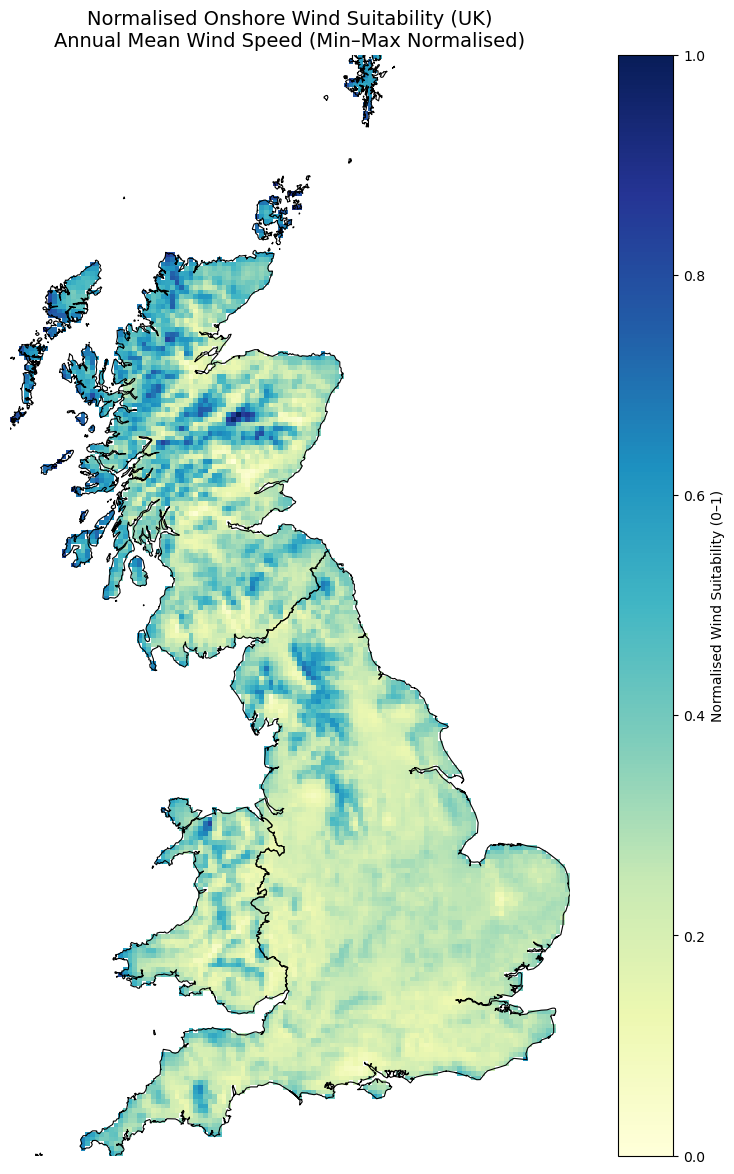

In [36]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

uk = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/UK Boundary/CTRY_DEC_2021_UK_BUC.shp"
).to_crs("EPSG:27700")
uk = uk[uk["CTRY21NM"].isin(["England", "Scotland", "Wales"])].copy()

ds = xr.open_dataset(
    "/Users/qinyu/Desktop/Spatial Data/datasets/wind_speed.nc"
)

wind_speed = ds["wind_speed"]

wind_speed = wind_speed.rio.set_spatial_dims(
    x_dim="x",
    y_dim="y",
    inplace=False
)

wind_speed = wind_speed.rio.write_crs(
    "EPSG:27700",
    inplace=False
)

wind_uk = wind_speed.rio.clip(
    uk.geometry,
    uk.crs,
    drop=True
)

wind_annual = wind_uk.mean(dim="season")


wind_norm = (wind_annual - wind_annual.min()) / (
    wind_annual.max() - wind_annual.min()
)

fig, ax = plt.subplots(figsize=(10, 12))

wind_norm.plot(
    ax=ax,
    cmap="YlGnBu",
    cbar_kwargs={"label": "Normalised Wind Suitability (0–1)"}
)

uk.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black"
)

ax.set_title(
    "Normalised Onshore Wind Suitability (UK)\n"
    "Annual Mean Wind Speed (Min–Max Normalised)",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


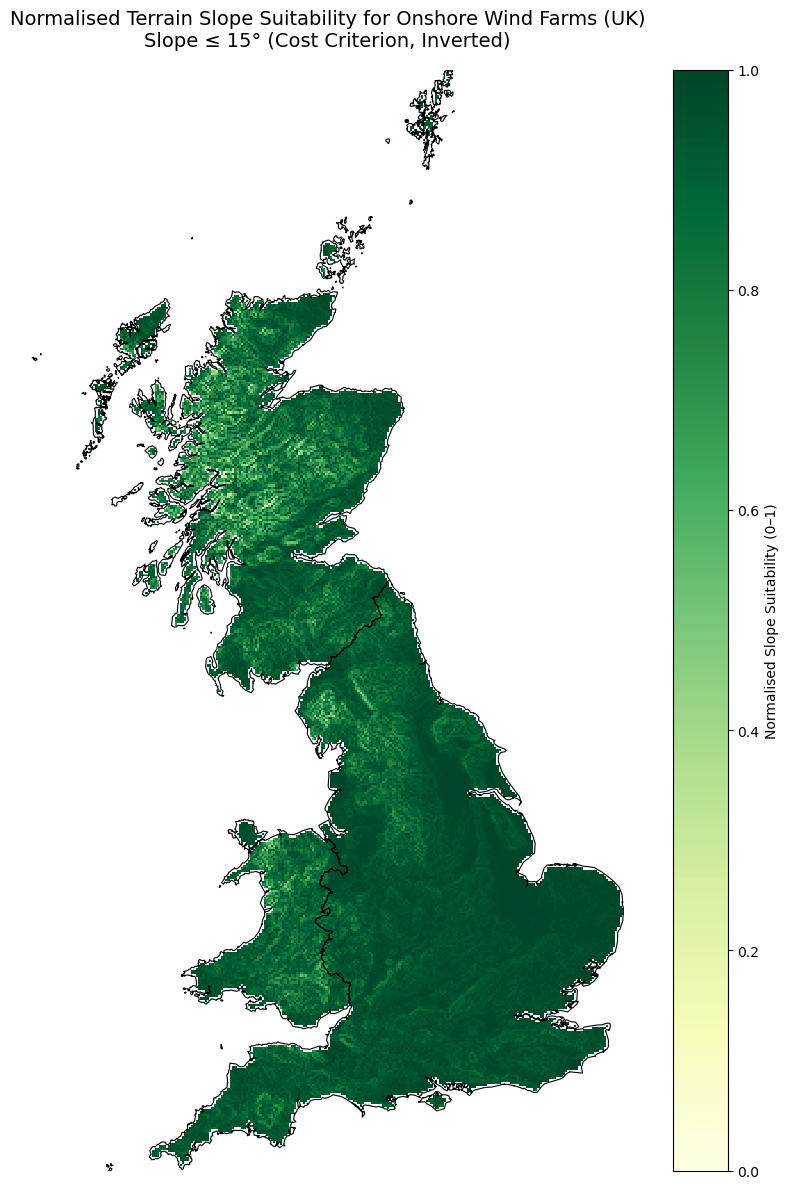

In [37]:
import rioxarray as rxr
import xarray as xr
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt


uk = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/UK Boundary/CTRY_DEC_2021_UK_BUC.shp"
).to_crs("EPSG:27700")
uk = uk[uk["CTRY21NM"].isin(["England", "Scotland", "Wales"])].copy()

dem = rxr.open_rasterio(
    "/Users/qinyu/Desktop/Spatial Data/terrain.tif",
    masked=True
).squeeze()

dem = dem.rio.write_crs("EPSG:27700", inplace=False)


dem_uk = dem.rio.clip(
    uk.geometry,
    uk.crs,
    drop=True
)

dx = dem_uk.rio.resolution()[0]
dy = dem_uk.rio.resolution()[1]

grad_y, grad_x = np.gradient(dem_uk.values, dy, dx)

slope = xr.DataArray(
    np.degrees(np.arctan(np.sqrt(grad_x**2 + grad_y**2))),
    coords=dem_uk.coords,
    dims=dem_uk.dims
)

slope_threshold = 15
slope_feasible = slope.where(slope <= slope_threshold)

slope_norm = 1 - (
    (slope_feasible - slope_feasible.min()) /
    (slope_feasible.max() - slope_feasible.min())
)

fig, ax = plt.subplots(figsize=(10, 12))

slope_norm.plot(
    ax=ax,
    cmap="YlGn",
    cbar_kwargs={"label": "Normalised Slope Suitability (0–1)"}
)

uk.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black"
)

ax.set_title(
    "Normalised Terrain Slope Suitability for Onshore Wind Farms (UK)\n"
    "Slope ≤ 15° (Cost Criterion, Inverted)",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


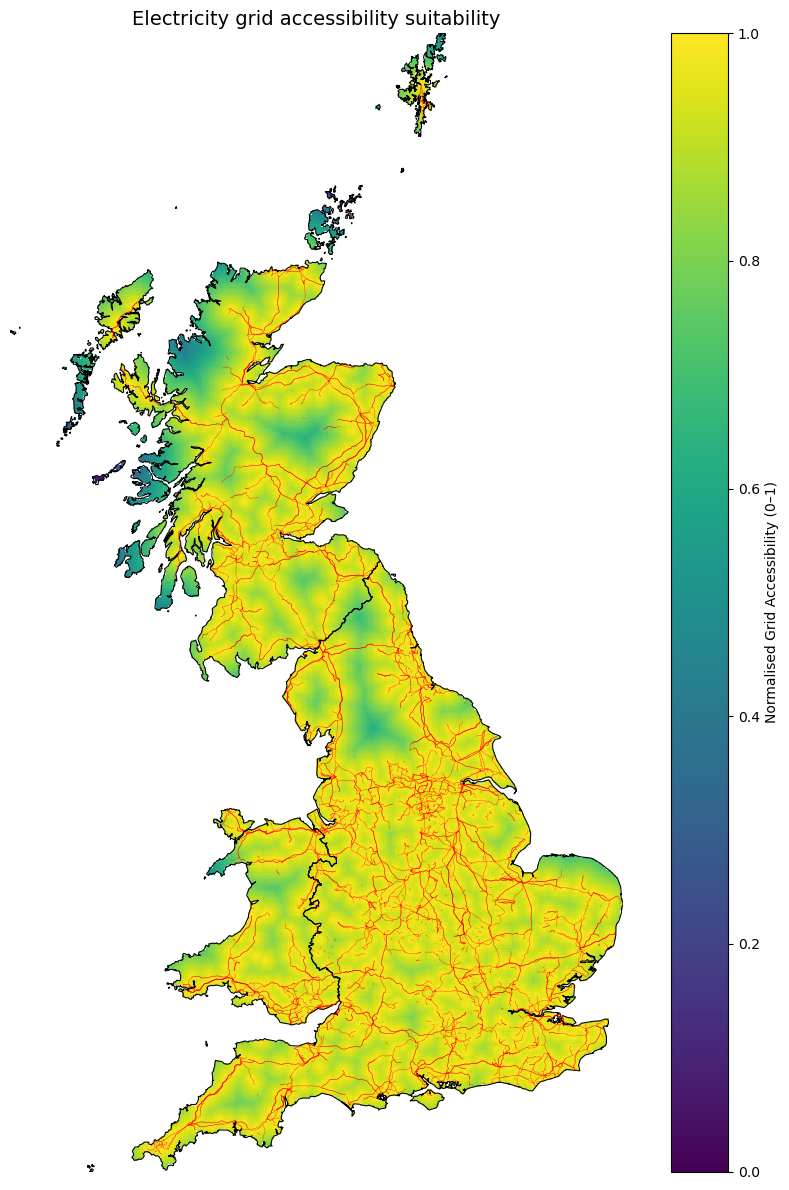

In [38]:
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from rasterio import features
from scipy.ndimage import distance_transform_edt

uk = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/UK Boundary/CTRY_DEC_2021_UK_BUC.shp"
).to_crs("EPSG:27700")
uk = uk[uk["CTRY21NM"].isin(["England", "Scotland", "Wales"])].copy()

dem = rxr.open_rasterio(
    "/Users/qinyu/Desktop/Spatial Data/terrain.tif",
    masked=True
).squeeze()

dem = dem.rio.write_crs("EPSG:27700", inplace=False)

dem_uk = dem.rio.clip(
    uk.geometry,
    uk.crs,
    drop=True
)

grid = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/datasets/uk_transmission_lines.geojson"
).to_crs("EPSG:27700")
grid = gpd.clip(grid, uk) 
grid_buffer = grid.copy()
grid_buffer["geometry"] = grid_buffer.geometry.buffer(250)  # meters

transform = dem_uk.rio.transform()
out_shape = dem_uk.shape

grid_raster = features.rasterize(
    ((geom, 1) for geom in grid_buffer.geometry),
    out_shape=out_shape,
    transform=transform,
    fill=0,
    dtype="uint8"
)

grid_raster = xr.DataArray(
    grid_raster,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)

dist_grid = distance_transform_edt(grid_raster.values == 0)

pixel_size = abs(dem_uk.rio.resolution()[0])
dist_grid = dist_grid * pixel_size

dist_grid = xr.DataArray(
    dist_grid,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)

dist_grid_uk = dist_grid.where(dem_uk.notnull())

grid_norm = 1 - (
    (dist_grid_uk - dist_grid_uk.min()) /
    (dist_grid_uk.max() - dist_grid_uk.min())
)

fig, ax = plt.subplots(figsize=(10, 12))

grid_norm.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Normalised Grid Accessibility (0–1)"}
)

uk.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black"
)

grid.plot(
    ax=ax,
    color="red",
    linewidth=0.4,
    alpha=0.6
)

ax.set_title(
    "Electricity grid accessibility suitability",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


In [39]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.


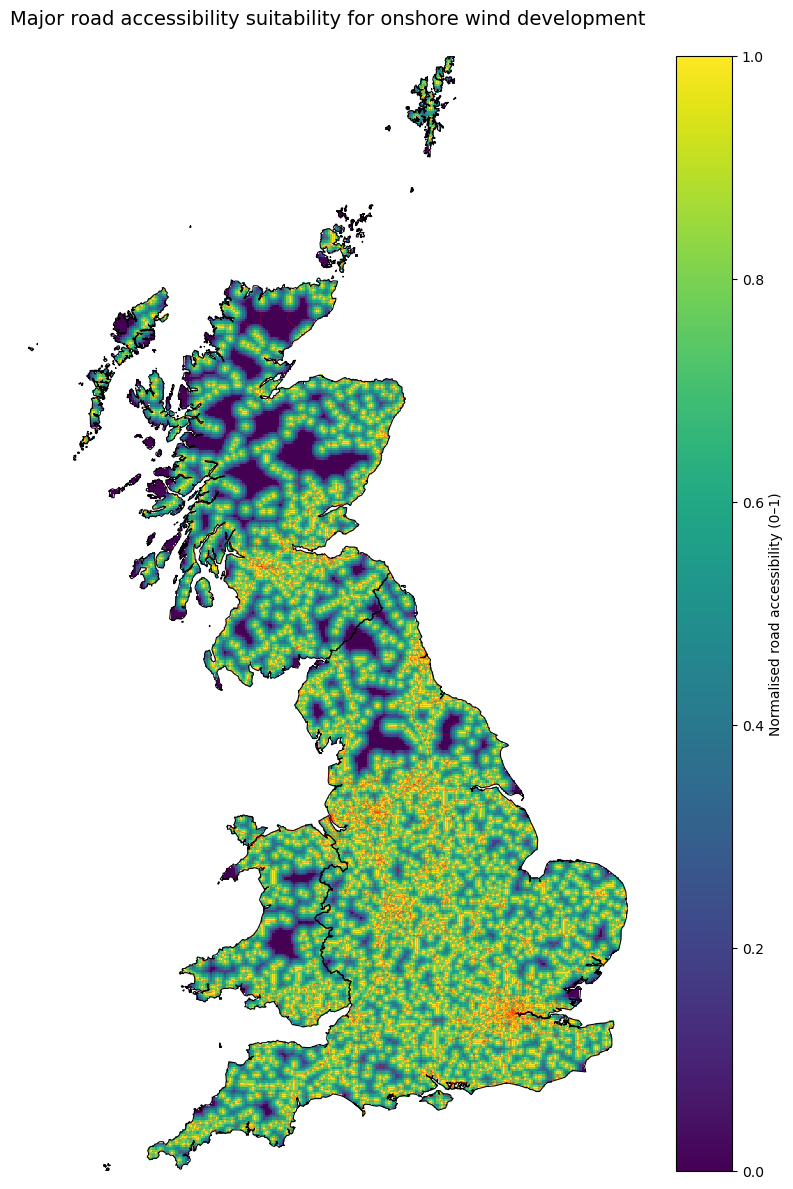

In [40]:
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from rasterio import features
from scipy.ndimage import distance_transform_edt
import contextily as ctx

UK_SHAPE = "/Users/qinyu/Desktop/Spatial Data/UK Boundary/CTRY_DEC_2021_UK_BUC.shp"
DEM_PATH = "/Users/qinyu/Desktop/Spatial Data/terrain.tif"
ROAD_PATH = "/Users/qinyu/Desktop/Spatial Data/mrdb-2024/MRDB_2024_published.shp"

uk = gpd.read_file(UK_SHAPE).to_crs("EPSG:27700")
uk = uk[uk["CTRY21NM"].isin(["England", "Scotland", "Wales"])].copy()

dem = rxr.open_rasterio(
    DEM_PATH,
    masked=True
).squeeze()

dem = dem.rio.write_crs("EPSG:27700", inplace=False)

dem_uk = dem.rio.clip(
    uk.geometry,
    uk.crs,
    drop=True
)


roads = gpd.read_file(ROAD_PATH).to_crs("EPSG:27700")


roads_buffer = roads.copy()
roads_buffer["geometry"] = roads_buffer.geometry.buffer(300)  # meters


transform = dem_uk.rio.transform()
out_shape = dem_uk.shape

roads_raster = features.rasterize(
    ((geom, 1) for geom in roads_buffer.geometry),
    out_shape=out_shape,
    transform=transform,
    fill=0,
    dtype="uint8"
)

roads_raster = xr.DataArray(
    roads_raster,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)


dist_road = distance_transform_edt(roads_raster.values == 0)

pixel_size = abs(dem_uk.rio.resolution()[0])
dist_road = dist_road * pixel_size  # meters

dist_road = xr.DataArray(
    dist_road,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)


dist_road_uk = dist_road.where(dem_uk.notnull())


cap = np.nanpercentile(dist_road_uk, 95)
dist_capped = xr.where(dist_road_uk > cap, cap, dist_road_uk)

road_norm = 1 - (
    (dist_capped - dist_capped.min()) /
    (dist_capped.max() - dist_capped.min())
)


fig, ax = plt.subplots(figsize=(10, 12))

im = road_norm.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Normalised road accessibility (0–1)"},
    zorder=2
)



# UK boundary
uk.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black",
    zorder=3
)

# Optional: overlay roads (very thin)
roads.plot(
    ax=ax,
    color="red",
    linewidth=0.3,
    alpha=0.5,
    zorder=4
)

ax.set_title(
    "Major road accessibility suitability for onshore wind development",
    fontsize=14,
    pad=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


In [41]:
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from rasterio import features
from rasterio.enums import Resampling
from scipy.ndimage import distance_transform_edt


In [42]:
# UK boundary
uk = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/UK Boundary/CTRY_DEC_2021_UK_BUC.shp"
).to_crs("EPSG:27700")
uk = uk[uk["CTRY21NM"].isin(["England", "Scotland", "Wales"])].copy()
# DEM = analysis template
dem = rxr.open_rasterio(
    "/Users/qinyu/Desktop/Spatial Data/terrain.tif",
    masked=True
).squeeze().rio.write_crs("EPSG:27700")

dem_uk = dem.rio.clip(uk.geometry, uk.crs, drop=True)

print("DEM shape:", dem_uk.shape)


DEM shape: (483, 260)


In [43]:
import xarray as xr

# 1. Open NetCDF properly
ds_wind = xr.open_dataset(
    "/Users/qinyu/Desktop/Spatial Data/datasets/wind_speed.nc"
)

print(ds_wind)   
 
wind = ds_wind["wind_speed"].mean("season")

wind = wind.rio.write_crs("EPSG:27700")
 
wind_rs = wind.rio.reproject_match(dem_uk)
 
W = (wind_rs - wind_rs.min()) / (wind_rs.max() - wind_rs.min())

print("Wind suitability shape:", W.shape)


<xarray.Dataset> Size: 987kB
Dimensions:      (y: 235, x: 131, season: 4)
Coordinates:
  * y            (y) int32 940B 12500 17500 22500 ... 1172500 1177500 1182500
  * x            (x) int32 524B 2500 7500 12500 17500 ... 642500 647500 652500
  * season       (season) object 32B 'spring' 'summer' 'autumn' 'winter'
Data variables:
    wind_speed   (season, y, x) float64 985kB ...
    spatial_ref  int32 4B ...
Wind suitability shape: (483, 260)


In [44]:
print("Wind suitability shape:", W.shape)


Wind suitability shape: (483, 260)


In [45]:
 
xres, yres = dem_uk.rio.resolution()

 
dzdx, dzdy = np.gradient(dem_uk.values, xres, yres)
slope_np = np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))

 
slope = xr.DataArray(
    slope_np,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)

 
slope_ok = slope.where(slope <= 15)

 
S = 1 - (
    (slope_ok - slope_ok.min()) /
    (slope_ok.max() - slope_ok.min())
)

print("Slope suitability shape:", S.shape)
print("Slope min/max:", float(S.min()), float(S.max()))


Slope suitability shape: (483, 260)
Slope min/max: 0.0 1.0


In [46]:
 grid = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/datasets/uk_transmission_lines.geojson"
).to_crs("EPSG:27700")

# Clip to UK
grid = gpd.clip(grid, uk)

print("Number of grid features:", len(grid))
 
grid_raster = features.rasterize(
    ((geom, 1) for geom in grid.geometry if geom is not None),
    out_shape=dem_uk.shape,
    transform=dem_uk.rio.transform(),
    fill=0,
    dtype="uint8"
)
 
xres, yres = dem_uk.rio.resolution()
dist_grid_np = distance_transform_edt(grid_raster == 0) * abs(xres)

dist_grid = xr.DataArray(
    dist_grid_np,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)
 
G = 1 - (
    (dist_grid - dist_grid.min()) /
    (dist_grid.max() - dist_grid.min())
)

print("Grid suitability shape:", G.shape)
print("Grid min/max:", float(G.min()), float(G.max()))


Number of grid features: 14274
Grid suitability shape: (483, 260)
Grid min/max: 0.0 1.0


/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


In [47]:
 
roads = gpd.read_file(
    "/Users/qinyu/Desktop/Spatial Data/mrdb-2024/MRDB_2024_published.shp"
).to_crs("EPSG:27700")
 
roads = gpd.clip(roads, uk)

print("Number of road features:", len(roads))
 
roads_raster = features.rasterize(
    ((geom, 1) for geom in roads.geometry if geom is not None),
    out_shape=dem_uk.shape,
    transform=dem_uk.rio.transform(),
    fill=0,
    dtype="uint8"
)
 
xres, yres = dem_uk.rio.resolution()
dist_road_np = distance_transform_edt(roads_raster == 0) * abs(xres)

dist_road = xr.DataArray(
    dist_road_np,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)
 
D = 1 - (
    (dist_road - dist_road.min()) /
    (dist_road.max() - dist_road.min())
)

print("Road suitability shape:", D.shape)
print("Road min/max:", float(D.min()), float(D.max()))


Number of road features: 17933
Road suitability shape: (483, 260)
Road min/max: 0.0 1.0


/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


In [48]:
 
pop = rxr.open_rasterio(
    "/Users/qinyu/Desktop/Spatial Data/population.tif",
    masked=True
).squeeze()
 
pop_rs = pop.rio.reproject_match(
    dem_uk,
    resampling=Resampling.nearest
)

pop_excl = pop_rs > 1000

 
PA_SHAPE = (
    "/Users/qinyu/Desktop/Spatial Data/WDPA_WDOECM_Jan2026_Public_EU_shp_0/WDPA_WDOECM_Jan2026_Public_EU_shp-polygons.shp"
)

pa = gpd.read_file(PA_SHAPE).to_crs("EPSG:27700")

 
pa = gpd.clip(pa, uk)
 
pa = pa[pa.geometry.notnull() & ~pa.geometry.is_empty]
pa = pa[pa.is_valid]

print("Number of protected areas:", len(pa))

 
pa_raster_np = features.rasterize(
    ((geom, 1) for geom in pa.geometry),
    out_shape=dem_uk.shape,
    transform=dem_uk.rio.transform(),
    fill=0,
    dtype="uint8"
)

pa_raster = xr.DataArray(
    pa_raster_np,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)

pa_excl = pa_raster == 1

 
land = dem_uk.notnull()

excluded = xr.where(pop_excl | pa_excl, 1, 0).where(land)
allowed = xr.where(excluded == 1, 0, 1).where(land)
 
print("Allowed cells:", int(np.nansum(allowed)))
print("Unique allowed values:",
      np.unique(allowed.values[~np.isnan(allowed.values)]))


/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


Number of protected areas: 8329
Allowed cells: 25360
Unique allowed values: [0. 1.]


In [49]:
 SI = (
    0.50 * W +
    0.15 * S +
    0.25 * G +
    0.1 * D
)
 
SI = SI.where(allowed == 1)

print("SI min:", float(SI.min()))
print("SI max:", float(SI.max()))
print("Non-NaN SI cells:", int(np.sum(~np.isnan(SI.values))))


SI min: 0.46226736546868463
SI max: 0.8754214838752277
Non-NaN SI cells: 23475


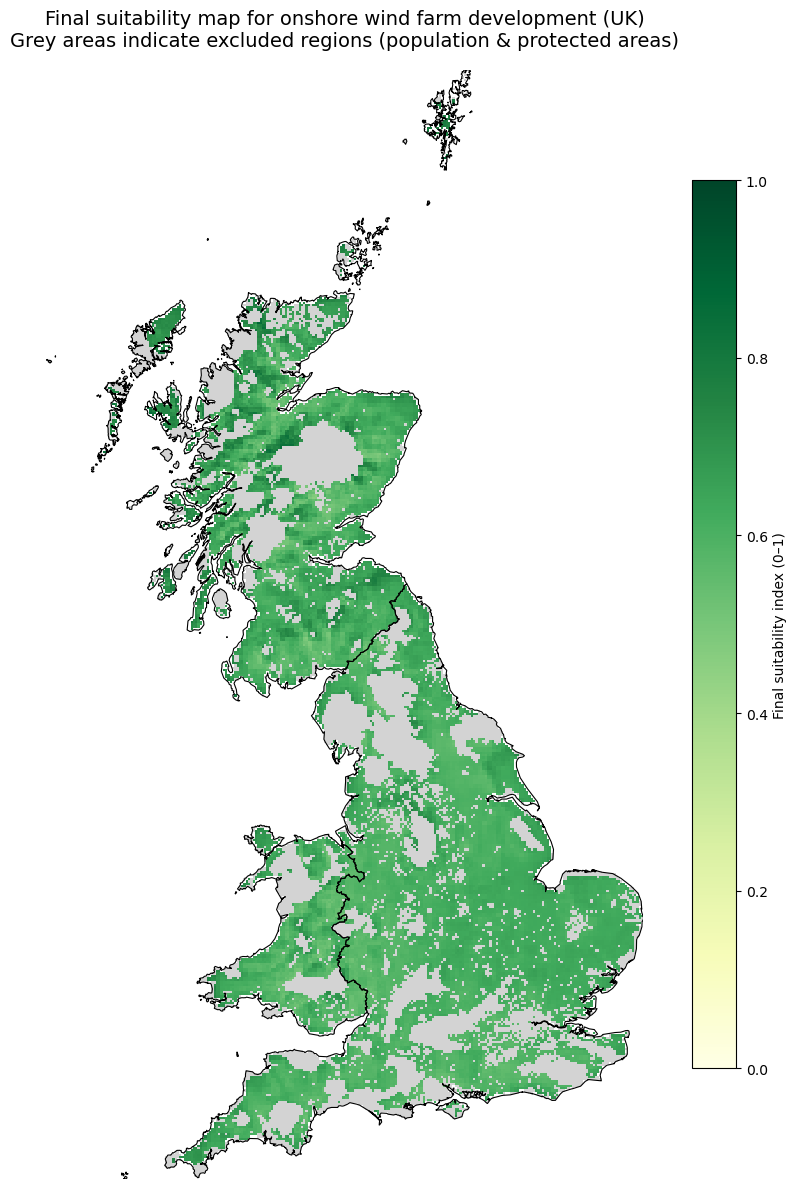

In [50]:
 from matplotlib.colors import ListedColormap

excluded = allowed.where(allowed == 0)

fig, ax = plt.subplots(figsize=(10, 12))
 
SI.plot(
    ax=ax,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    cbar_kwargs={
        "label": "Final suitability index (0–1)",
        "shrink": 0.8
    }
)
 
excluded.plot(
    ax=ax,
    cmap=ListedColormap(["lightgrey"]),
    add_colorbar=False
)
 
uk.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black"
)

ax.set_title(
    "Final suitability map for onshore wind farm development (UK)\n"
    "Grey areas indicate excluded regions (population & protected areas)",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


Existing onshore wind farms ≥50 MW: 116
Allowed cells after existing wind exclusion: 18829
SI_final min/max: 0.46760167393187485 0.8754214838752277
Number of candidate points: 798
Final selected sites: 20
By region: {'Scotland': 12, 'England': 6, 'Wales': 2}


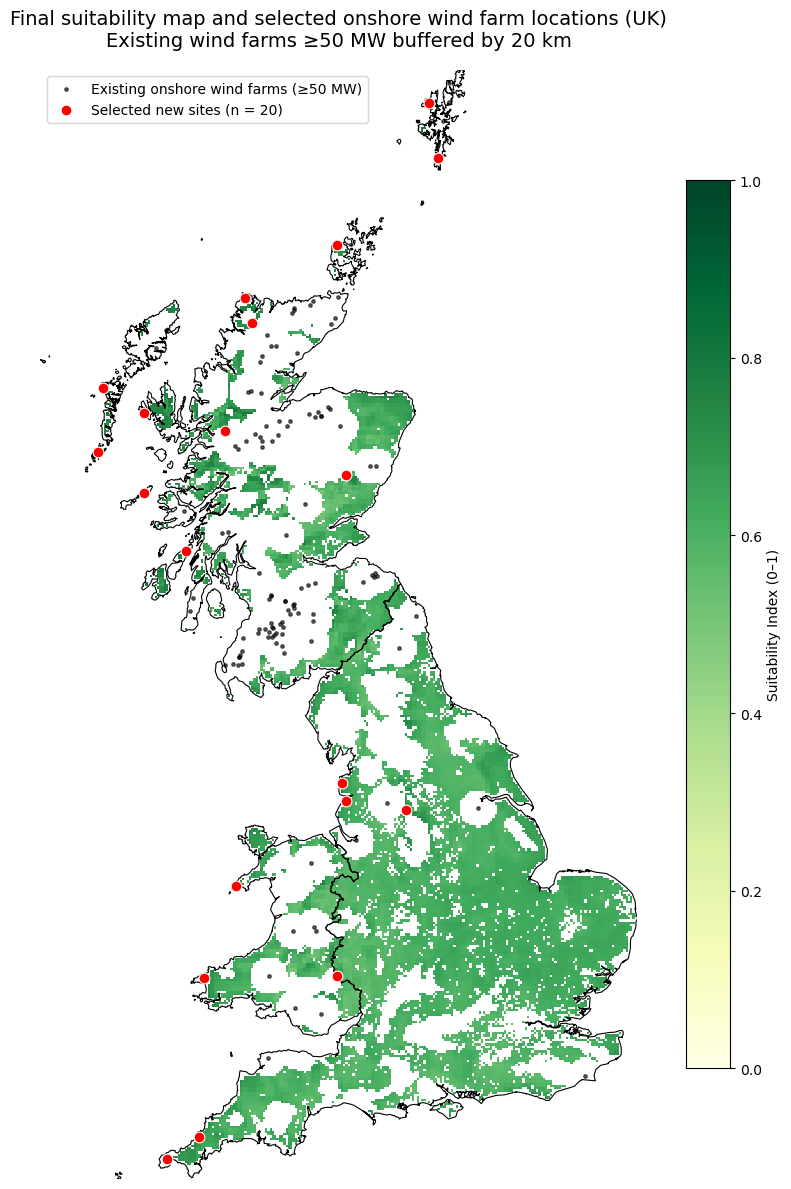

In [51]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
from shapely.geometry import Point
from rasterio import features
import matplotlib.pyplot as plt
 
REPD_CSV = "/Users/qinyu/Desktop/AS2 Spatial ES/REPD_Publication_Q3_2025.csv"
 
df = pd.read_csv(REPD_CSV, encoding="latin1")

df = df[
    df["Country"].isin(["England", "Scotland", "Wales"]) &
    df["Technology Type"].str.contains("Wind", case=False, na=False) &
    df["Technology Type"].str.contains("Onshore", case=False, na=False)
]

valid_status = [
    "Operational",
    "Under Construction",
    "Planning Permission Granted",
    "Awaiting Construction",
    "Application Submitted"
]

df = df[df["Development Status"].isin(valid_status)]

df["Installed Capacity (MWelec)"] = pd.to_numeric(
    df["Installed Capacity (MWelec)"], errors="coerce"
)

df = df[df["Installed Capacity (MWelec)"] >= 50]
df = df.dropna(subset=["X-coordinate", "Y-coordinate"])

existing_wind = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["X-coordinate"], df["Y-coordinate"]
    ),
    crs="EPSG:27700"
)

existing_wind = gpd.clip(existing_wind, uk)

print("Existing onshore wind farms ≥50 MW:", len(existing_wind))
 
BUFFER_DIST = 20000  # meters
existing_buffer = existing_wind.copy()
existing_buffer["geometry"] = existing_buffer.geometry.buffer(BUFFER_DIST)
 
existing_excl_np = features.rasterize(
    ((geom, 1) for geom in existing_buffer.geometry),
    out_shape=dem_uk.shape,
    transform=dem_uk.rio.transform(),
    fill=0,
    dtype="uint8"
)

existing_excl = xr.DataArray(
    existing_excl_np,
    coords=dem_uk.coords,
    dims=dem_uk.dims
)
 
allowed_final = xr.where(
    existing_excl == 1,
    0,
    allowed
).where(dem_uk.notnull())

print("Allowed cells after existing wind exclusion:",
      int(np.nansum(allowed_final)))
 
SI_final = (
    0.50 * W +
    0.15 * S +
    0.25 * G +
    0.10 * D
)

SI_final = SI_final.where(allowed_final == 1)

print("SI_final min/max:",
      float(SI_final.min()), float(SI_final.max()))


SI_THRESHOLD = 0.7

mask = SI_final >= SI_THRESHOLD
 
ys, xs = np.where(mask.values)
 
points = [
    Point(SI_final.x.values[x], SI_final.y.values[y])
    for y, x in zip(ys, xs)
]
 
candidates = gpd.GeoDataFrame(
    {
        "SI": SI_final.values[ys, xs]
    },
    geometry=points,
    crs="EPSG:27700"
)

 
candidates = candidates.sort_values(
    by="SI", ascending=False
).reset_index(drop=True)

print("Number of candidate points:", len(candidates))

 
candidates["region"] = gpd.sjoin(
    candidates,
    uk[["geometry", "CTRY21NM"]],
    how="left",
    predicate="within"
)["CTRY21NM"].values

 
region_quota = {
    "Scotland": 12,
    "England": 6,
    "Wales": 2
}

region_count = {
    "Scotland": 0,
    "England": 0,
    "Wales": 0
}

 
selected = []
MIN_DIST = 20000  # 20 km
N_SITES = 20

for _, row in candidates.iterrows():

    region = row["region"]
 
    if region not in region_quota:
        continue
 
    if region_count[region] >= region_quota[region]:
        continue
 
    if len(selected) > 0:
        dists = [row.geometry.distance(s.geometry) for s in selected]
        if min(dists) < MIN_DIST:
            continue
 
    selected.append(row)
    region_count[region] += 1

    if len(selected) == N_SITES:
        break

 
final_sites = gpd.GeoDataFrame(
    selected,
    crs="EPSG:27700"
)

final_sites["site_id"] = range(1, len(final_sites) + 1)

print("Final selected sites:", len(final_sites))
print("By region:", region_count)
 
fig, ax = plt.subplots(figsize=(10, 12))

SI_final.plot(
    ax=ax,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    cbar_kwargs={
        "label": "Suitability Index (0–1)",
        "shrink": 0.8
    }
)

existing_wind.plot(
    ax=ax,
    color="black",
    markersize=6,
    alpha=0.6,
    label="Existing onshore wind farms (≥50 MW)",
    zorder=4
)

final_sites.plot(
    ax=ax,
    color="red",
    markersize=60,
    edgecolor="white",
    linewidth=0.8,
    label="Selected new sites (n = 20)",
    zorder=5
)

uk.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black"
)

ax.set_title(
    "Final suitability map and selected onshore wind farm locations (UK)\n"
    "Existing wind farms ≥50 MW buffered by 20 km",
    fontsize=14
)

ax.set_axis_off()
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [52]:
import geopandas as gpd
 
final_sites = final_sites.drop(
    columns=["index_right", "index_left"],
    errors="ignore"
)
 
final_sites = gpd.sjoin(
    final_sites,
    uk[["geometry", "CTRY21NM"]],
    how="left",
    predicate="within"
)
 
final_sites = final_sites.rename(
    columns={"CTRY21NM": "Region"}
)
 
final_sites["Easting"] = final_sites.geometry.x
final_sites["Northing"] = final_sites.geometry.y
 
site_table = final_sites[
    ["site_id", "Region", "SI", "Easting", "Northing"]
].sort_values("site_id")

 
site_table["SI"] = site_table["SI"].round(3)
site_table["Easting"] = site_table["Easting"].round(0)
site_table["Northing"] = site_table["Northing"].round(0)
 
print(site_table)
 



     site_id    Region     SI   Easting   Northing
0          1  Scotland  0.875  438750.0  1121250.0
1          2  Scotland  0.871  236250.0   941250.0
2          3  Scotland  0.849  118750.0   843750.0
3          4  Scotland  0.839  206250.0   823750.0
4          5  Scotland  0.837   73750.0   871250.0
5          6  Scotland  0.836  428750.0  1181250.0
6          7  Scotland  0.836   68750.0   801250.0
13         8  Scotland  0.821  338750.0   776250.0
14         9  Scotland  0.820  163750.0   693750.0
15        10  Scotland  0.820  328750.0  1026250.0
16        11  Scotland  0.819  228750.0   968750.0
17        12  Scotland  0.819  118750.0   756250.0
78        13     Wales  0.786  218750.0   328750.0
126       14   England  0.770  178750.0    56250.0
162       15   England  0.763  338750.0   421250.0
168       16   England  0.762  403750.0   411250.0
175       17   England  0.761  328750.0   231250.0
187       18     Wales  0.758  183750.0   228750.0
256       19   England  0.749  

In [53]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point
 
import geopandas as gpd

GRID_PATH = "/Users/qinyu/Desktop/Spatial Data/datasets/uk_transmission_lines.geojson"

grid_lines = gpd.read_file(GRID_PATH).to_crs(final_sites.crs)
 
final_sites["dist_grid_km"] = final_sites.geometry.apply(
    lambda geom: grid_lines.distance(geom).min() / 1000
)
 
final_sites = final_sites.to_crs("EPSG:27700")
 
xs = xr.DataArray(final_sites.geometry.x.values, dims="site")
ys = xr.DataArray(final_sites.geometry.y.values, dims="site")

final_sites["wind_speed"] = wind_rs.sel(
    x=xs,
    y=ys,
    method="nearest"
).values
 
grid_lines = grid_lines.to_crs(final_sites.crs)

final_sites["dist_grid_km"] = final_sites.geometry.apply(
    lambda geom: grid_lines.distance(geom).min() / 1000
)
 
INSTALLED_CAPACITY_MW = 500          # per site
PROJECT_LIFETIME = 25                # years
DISCOUNT_RATE = 0.05                 # NPV & LCOE
ELECTRICITY_PRICE = 103              # USD/MWh

CAPEX_INSTALL_PER_MW = 2_000_000     # USD/MW
GRID_COST_PER_MW_KM = 590            # USD/MW/km (inland)
 
def calc_turbine_speed(speed, turbine_height=70, data_height=10, alpha=1/7):
    return speed * (turbine_height / data_height) ** alpha

final_sites["turbine_speed"] = calc_turbine_speed(final_sites["wind_speed"])
 
wind_speeds = np.arange(0, 25)

power_curve = np.array([
    0, 0, 0, 102, 257, 471, 750, 1194, 1713, 2227, 2465, 2500,
    2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500,
    2500, 2500, 2500, 2400, 2250
])  # kW

def speed_to_power(speed):
    speed = np.clip(speed, 0, 24)
    return np.interp(speed, wind_speeds, power_curve)

final_sites["turbine_power_kW"] = final_sites["turbine_speed"].apply(speed_to_power)
 
RATED_POWER_KW = 2500

final_sites["capacity_factor"] = (
    final_sites["turbine_power_kW"] / RATED_POWER_KW
).clip(0, 1)

final_sites["annual_energy_MWh"] = (
    INSTALLED_CAPACITY_MW * 8760 * final_sites["capacity_factor"]
)

 
final_sites["annual_revenue_USD"] = (
    final_sites["annual_energy_MWh"] * ELECTRICITY_PRICE
)
 
final_sites["capex_install_USD"] = (
    INSTALLED_CAPACITY_MW * CAPEX_INSTALL_PER_MW
)

final_sites["capex_grid_USD"] = (
    INSTALLED_CAPACITY_MW * GRID_COST_PER_MW_KM * final_sites["dist_grid_km"]
)

final_sites["capex_total_USD"] = (
    final_sites["capex_install_USD"] + final_sites["capex_grid_USD"]
)
 
def calculate_npv(capex, annual_revenue, r, n):
    discounted_revenue = sum(
        annual_revenue / ((1 + r) ** t) for t in range(1, n + 1)
    )
    return discounted_revenue - capex

final_sites["NPV_USD"] = final_sites.apply(
    lambda row: calculate_npv(
        row["capex_total_USD"],
        row["annual_revenue_USD"],
        DISCOUNT_RATE,
        PROJECT_LIFETIME
    ),
    axis=1
)
 
def calculate_lcoe(capex, annual_energy, r, n):
    discounted_energy = sum(
        annual_energy / ((1 + r) ** t) for t in range(1, n + 1)
    )
    return capex / discounted_energy

final_sites["LCOE_USD_per_MWh"] = final_sites.apply(
    lambda row: calculate_lcoe(
        row["capex_total_USD"],
        row["annual_energy_MWh"],
        DISCOUNT_RATE,
        PROJECT_LIFETIME
    ),
    axis=1
)

 
results = final_sites[[
    "wind_speed",
    "dist_grid_km",
    "capacity_factor",
    "annual_energy_MWh",
    "annual_revenue_USD",
    "capex_total_USD",
    "NPV_USD",
    "LCOE_USD_per_MWh"
]].copy()

print(results)

results.to_csv("financial_results_20_sites.csv", index=False)


     wind_speed  dist_grid_km  capacity_factor  annual_energy_MWh  \
0      6.440868      6.309509         0.789022       3.455914e+06   
1      6.447285     15.779380         0.790764       3.463545e+06   
2      6.405315      9.447697         0.779369       3.413637e+06   
3      6.335720     19.809784         0.760475       3.330881e+06   
4      6.437842     45.941917         0.788200       3.452315e+06   
5      6.287695     22.018607         0.747437       3.273773e+06   
6      6.537413     74.467764         0.815232       3.570718e+06   
13     6.170322     14.997012         0.715571       3.134202e+06   
14     6.056327     20.846326         0.684617       2.998624e+06   
15     6.017459     21.299920         0.673962       2.951955e+06   
16     6.329510     42.620288         0.758789       3.323496e+06   
17     6.468591     68.112510         0.796548       3.488880e+06   
78     5.718022     23.816733         0.591878       2.592426e+06   
126    5.377357      4.378467     